In [1]:
import pandas as pd
import numpy as np

In [10]:
mar = pd.read_csv("mcu.csv")
mar

,movie_title,mcu_phase,release_date,tomato_meter,audience_score,movie_duration,production_budget,opening_weekend,domestic_box_office,worldwide_box_office
0,Iron Man,Phase 1,2008-05-02,94,91,126.0,140000000.0,102118668.0,319034126.0,585796247.0
1,The Incredible Hulk,Phase 1,2008-06-13,67,70,112.0,137500000.0,55414050.0,134806913.0,265573859.0
2,Iron Man 2,Phase 1,2010-05-07,72,71,124.0,200000000.0,128122480.0,312433331.0,621156389.0
3,Thor,Phase 1,2011-05-06,77,76,114.0,150000000.0,65723338.0,181030624.0,449326618.0
4,Captain America The First Avenger,Phase 1,2011-07-22,80,75,124.0,140000000.0,65058524.0,176654505.0,370569774.0
...,...,...,...,...,...,...,...,...,...,...
57,Wonder Man,Phase 6,2026-01-27,91,82,NaN,NaN,NaN,NaN,NaN
58,Your Friendly Neighborhood Spider-Man Season 2,Phase 6,2026-09-01,95,65,NaN,NaN,NaN,NaN,NaN
59,Daredevil Born Again Season 2,Phase 6,2026-03-24,90,89,NaN,NaN,NaN,NaN,NaN
60,The Punisher One Last Kill,Phase 6,2026-05-12,87,90,NaN,NaN,NaN,NaN,NaN


In [88]:
mar = mar.dropna()
mar

,movie_title,mcu_phase,release_date,tomato_meter,audience_score,movie_duration,production_budget,opening_weekend,domestic_box_office,worldwide_box_office,budget_roll,total_box_office
2,Iron Man 2,Phase 1,2010-05-07,72,71,124.0,200000000.0,128122480.0,312433331.0,6.211564e+08,1.591667e+08,"$933,589,720.00"
3,Thor,Phase 1,2011-05-06,77,76,114.0,150000000.0,65723338.0,181030624.0,4.493266e+08,1.625000e+08,"$630,357,242.00"
4,Captain America The First Avenger,Phase 1,2011-07-22,80,75,124.0,140000000.0,65058524.0,176654505.0,3.705698e+08,1.633333e+08,"$547,224,279.00"
5,The Avengers,Phase 1,2012-05-04,91,91,143.0,220000000.0,207438708.0,623357910.0,1.518813e+09,1.700000e+08,"$2,142,170,898.00"
6,Iron Man 3,Phase 2,2013-05-03,79,78,130.0,200000000.0,174144585.0,409013994.0,1.214811e+09,1.866667e+08,"$1,623,825,246.00"
7,Thor The Dark World,Phase 2,2013-11-08,66,75,112.0,170000000.0,85737841.0,206362140.0,6.446025e+08,1.966667e+08,"$850,964,656.00"
8,Captain America The Winter Soldier,Phase 2,2014-04-04,90,92,136.0,170000000.0,95023721.0,259766572.0,7.144215e+08,1.800000e+08,"$974,188,075.00"
9,Guardians of the Galaxy,Phase 2,2014-08-01,91,92,121.0,170000000.0,94307658.0,333176600.0,7.733501e+08,1.700000e+08,"$1,106,526,747.00"
10,Avengers Age of Ultron,Phase 2,2015-05-01,76,82,141.0,365000000.0,191271109.0,459005868.0,1.395317e+09,2.350000e+08,"$1,854,322,847.00"
11,Ant-Man,Phase 2,2015-07-17,83,85,117.0,130000000.0,57225526.0,180202163.0,5.193120e+08,2.216667e+08,"$699,514,128.00"


In [16]:
money = mar.groupby(["mcu_phase"])[["production_budget","domestic_box_office","worldwide_box_office"]].mean()
money

,production_budget,domestic_box_office,worldwide_box_office
mcu_phase,,,
Phase 1,1.645833e+08,2.912196e+08,6.352060e+08
Phase 2,2.008333e+08,3.079212e+08,8.769691e+08
Phase 3,2.134545e+08,4.501295e+08,1.229760e+09
Phase 4,2.122857e+08,3.694680e+08,8.160761e+08
Phase 5,2.133333e+08,2.809202e+08,6.105627e+08
Phase 6,2.125000e+08,5.663434e+08,1.373187e+09


In [ ]:
def my_format(x):
    return f"${x:,.2f}"
money_format = money.applymap(my_format)  #.applymap applies to every cell
money_format

C:\Users\Invate\AppData\Local\Temp\ipykernel_26524\2270342678.py:3: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  money_format = money.applymap(my_format)


,production_budget,domestic_box_office,worldwide_box_office
mcu_phase,,,
Phase 1,"$164,583,333.33","$291,219,568.17","$635,205,979.17"
Phase 2,"$200,833,333.33","$307,921,222.83","$876,969,060.33"
Phase 3,"$213,454,545.45","$450,129,501.00","$1,229,759,662.55"
Phase 4,"$212,285,714.29","$369,468,022.14","$816,076,133.29"
Phase 5,"$213,333,333.33","$280,920,189.00","$610,562,653.50"
Phase 6,"$212,500,000.00","$566,343,393.50","$1,373,187,120.50"


In [ ]:
def profit(x):
    return (x[1] + x[2]) - x[0]

money["profit"] = money.apply(profit, axis=1)
money["profit_fmt"] = money["profit"].apply(lambda x: f"${x:,.2f}")
money["profit_fmt"]



C:\Users\Invate\AppData\Local\Temp\ipykernel_26524\3935533999.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  return (x[1] + x[2]) - x[0]


mcu_phase
Phase 1      $761,842,214.00
Phase 2      $984,056,949.83
Phase 3    $1,466,434,618.09
Phase 4      $973,258,441.14
Phase 5      $678,149,509.17
Phase 6    $1,727,030,514.00
Name: profit_fmt, dtype: object

In [31]:
rating = mar.groupby(["mcu_phase"])[["tomato_meter","audience_score"]].mean()
rating 

,tomato_meter,audience_score
mcu_phase,,
Phase 1,80.166667,79.000000
Phase 2,80.833333,84.000000
Phase 3,89.181818,83.272727
Phase 4,83.133333,84.000000
Phase 5,76.176471,75.294118
Phase 6,90.571429,85.857143


In [ ]:
rating.applymap(lambda x: f"{x:.2f}")


C:\Users\Invate\AppData\Local\Temp\ipykernel_26524\4096707708.py:1: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  rating.applymap(lambda x: f"{x:.2f}")


,tomato_meter,audience_score
mcu_phase,,
Phase 1,80.17,79.00
Phase 2,80.83,84.00
Phase 3,89.18,83.27
Phase 4,83.13,84.00
Phase 5,76.18,75.29
Phase 6,90.57,85.86


In [50]:
rate = rating["tomato_meter"] - rating["audience_score"]
rate

mcu_phase
Phase 1    1.166667
Phase 2   -3.166667
Phase 3    5.909091
Phase 4   -0.866667
Phase 5    0.882353
Phase 6    4.714286
dtype: float64

In [66]:
mar_rating = mar.groupby(["movie_title"])[["tomato_meter","audience_score"]].mean()
mar_rating_diff = mar_rating["tomato_meter"] - mar_rating["audience_score"]  #the bigger the difference the less popular it was with the audience
mar_rating_diff = mar_rating_diff.sort_values(ascending=False)

In [93]:
df = pd.DataFrame({
        "rating": mar_rating_diff
})
df

,rating
movie_title,
She-Hulk Attorney-at-Law,45.0
Eyes of Wakanda,41.0
Your Friendly Neighborhood Spider-Man,35.0
Captain Marvel,34.0
Ironheart,30.0
...,...
Deadpool & Wolverine,-17.0
The Marvels,-18.0
Captain America Brave New World,-30.0


In [89]:
total_box_office = mar["domestic_box_office"] + mar["worldwide_box_office"]
total_box_office_fmt = total_box_office.apply(lambda x: f"${x:,.2f}")
mar["total_box_office"] = total_box_office_fmt
mar.groupby(["movie_title","movie_duration"])[["total_box_office"]].sum()




,,total_box_office
movie_title,movie_duration,
Ant-Man,117.0,"$699,514,128.00"
Ant-Man and the Wasp,118.0,"$839,322,879.00"
Ant-Man and the Wasp Quantumania,125.0,"$690,576,089.00"
Avengers Age of Ultron,141.0,"$1,854,322,847.00"
Avengers Endgame,181.0,"$3,657,812,100.00"
Avengers Infinity War,149.0,"$2,731,230,521.00"
Black Panther,134.0,"$2,053,709,010.00"
Black Panther Wakanda Forever,161.0,"$1,313,037,896.00"
Black Widow,134.0,"$563,403,310.00"


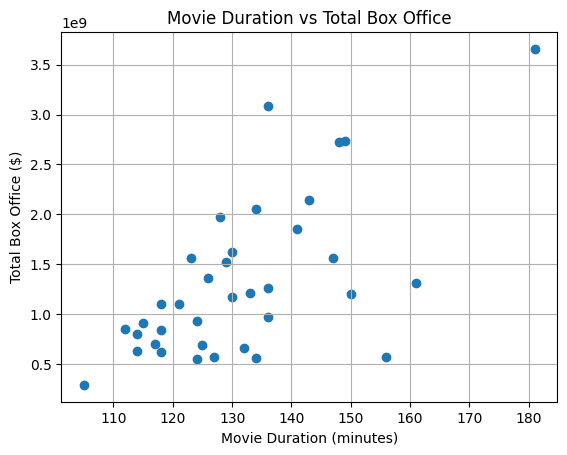

In [94]:
mar["total_box_office"] = total_box_office        # numeric
mar["total_box_office_fmt"] = total_box_office_fmt   # formatted

plt.scatter(mar["movie_duration"], mar["total_box_office"])
plt.xlabel("Movie Duration (minutes)")
plt.ylabel("Total Box Office ($)")
plt.title("Movie Duration vs Total Box Office")
plt.grid(True)
plt.show()


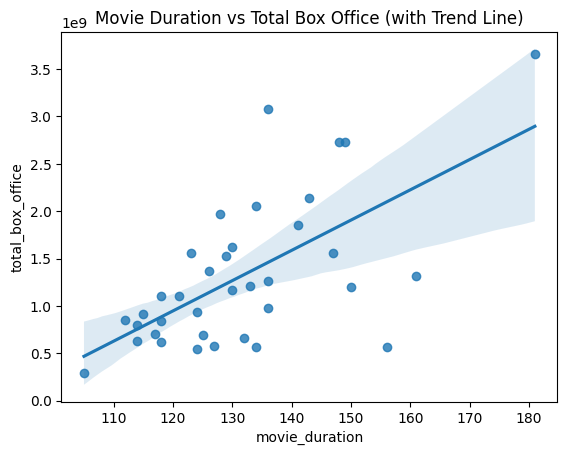

In [95]:
import seaborn as sns

sns.regplot(x="movie_duration", y="total_box_office", data=mar)
plt.title("Movie Duration vs Total Box Office (with Trend Line)")
plt.show()